In [1]:
import polars as pl

In [2]:
gldv_merged = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_top_countries_caption_labels.csv"
)
gldv_merged.head()

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str
"""4b966789e0572456""",30319,52.226169,21.023186,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PL""","""Poland""","""Europe""","""Eastern Europe""","""train""","""palace_castle""",0.9,"""Classical European building wi…"
"""16d8aa057cdd01b9""",25719,45.58359,9.27567,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""train""","""non_landmark""",0.9,"""Information board with text an…"
"""f1556e1eeeba213f""",36639,44.0446,-74.9325,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""train""","""non_landmark""",0.9,"""A small green plant growing on…"
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""non_landmark""",0.9,"""A serene stream flowing throug…"
"""3cdc355c6232712f""",12877,48.862444,2.395889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.9,"""A memorial wall with numerous …"


In [4]:
valid_df = gldv_merged.filter(pl.col("pred_label") != "non_landmark").with_columns(
    (pl.col("country") + "|" + pl.col("pred_label")).alias("stratify_key")
)
valid_df

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption,stratify_key
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str
"""4b966789e0572456""",30319,52.226169,21.023186,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PL""","""Poland""","""Europe""","""Eastern Europe""","""train""","""palace_castle""",0.9,"""Classical European building wi…","""Poland|palace_castle"""
"""202cd79556f30760""",104169,56.123889,-3.947778,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""palace_castle""",0.9,"""Ancient stone castle on a hill…","""United Kingdom|palace_castle"""
"""e9028e1ef00e6cff""",19756,43.275738,11.990018,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""train""","""arch_gate""",0.9,"""A stone arch gate with dark wo…","""Italy|arch_gate"""
"""6e901d6b9d4da278""",101718,43.881986,11.097297,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""train""","""tower""",0.9,"""A tall, striped tower with a l…","""Italy|tower"""
"""cc6b89c09b881029""",147865,31.21899,121.464163,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""CN""","""China""","""Asia""","""Eastern Asia""","""train""","""arch_gate""",0.9,"""Black metal gate with a plaque…","""China|arch_gate"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""514bdb4e3aaf5fc0""",73880,48.021944,11.861944,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""index""","""tower""",0.9,"""Gothic cathedral tower with in…","""Germany|tower"""
"""4f444b0bba8cdcc0""",31992,32.921,-117.253,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""index""","""arch_gate""",0.9,"""Stone building with a sign rea…","""United States|arch_gate"""
"""be3420d695838ba3""",49644,45.466669,9.197553,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""index""","""palace_castle""",0.9,"""A grand neoclassical building …","""Italy|palace_castle"""


In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(valid_df, test_size=0.2, random_state=42)
train_df, valid_df = train_test_split(train_df, test_size=0.1, random_state=42)

len(train_df), len(valid_df), len(test_df)

(601315, 66813, 167033)

In [8]:
train_df.head()

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption,stratify_key
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str
"""5224830a19a3f31c""",67085,34.1211,133.001,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""train""","""bridge""",0.9,"""A large suspension bridge with…","""Japan|bridge"""
"""b2d54da00a70bf24""",152227,53.006,7.192,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""train""","""bridge""",0.9,"""A red wooden bridge over a pon…","""Netherlands|bridge"""
"""843af7cc5cf86f15""",64521,48.431806,0.090278,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""arch_gate""",0.9,"""Classical French architecture …","""France|arch_gate"""
"""5c7b744683854d46""",58384,46.002,12.2867,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""index""","""palace_castle""",0.9,"""A medieval castle on a hilltop…","""Italy|palace_castle"""
"""a2510e80d6442d4f""",11054,40.42189,-3.682189,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""ES""","""Spain""","""Europe""","""Southern Europe""","""train""","""monument_statue""",0.9,"""A dynamic statue of a winged f…","""Spain|monument_statue"""


In [9]:
train_df.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/train.csv")
valid_df.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/valid.csv")
test_df.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/test.csv")

In [ ]:
import polars as pl
import json
import os
from PIL import Image
import sys

sys.path.append("..")
from src.data.query_builder import build_queries

In [ ]:
queries_df = (
    pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/test.csv")
    .with_row_index("row_idx")
    .rename({"pred_label": "category"})
)
queries = build_queries(queries_df)

In [ ]:
china_query = [
    q for q in queries if q["country"] == "China" and q["category"] == "arch_gate"
][0]
china_query

{'text': 'A arch_gate landmark located in China',
 'category': 'arch_gate',
 'country': 'China',
 'relevant_indices': [44,
  87,
  104,
  117,
  180,
  199,
  217,
  479,
  597,
  774,
  1005,
  1166,
  1187,
  1476,
  1591,
  1690,
  1707,
  1772,
  1916,
  2240,
  2328,
  2360,
  2361,
  2454,
  2474,
  2533,
  2581,
  3016,
  3031,
  3063,
  3082,
  3161,
  3222,
  3261,
  3304,
  3701,
  3709,
  3776,
  3888,
  3908,
  3927,
  3987,
  4094,
  4132,
  4144,
  4240,
  4501,
  4609,
  4618,
  4745,
  4828,
  4866,
  4995,
  5035,
  5046,
  5115,
  5165,
  5316,
  5378,
  5490,
  5623,
  5772,
  5864,
  6160,
  6280,
  6390,
  6495,
  6573,
  6720,
  6727,
  6752,
  6798,
  6873,
  6984,
  7118,
  7137,
  7231,
  7235,
  7282,
  7451,
  7456,
  7620,
  7671,
  7700,
  7714,
  7899,
  8036,
  8104,
  8176,
  8637,
  8772,
  8842,
  8903,
  8941,
  8991,
  8997,
  9275,
  9305,
  9352,
  9410,
  9607,
  9684,
  9744,
  9810,
  9866,
  10036,
  10068,
  10083,
  10219,
  10336,
  10348,
 

In [ ]:
meta_df = json.loads(
    open("../index/gldv-v2/baseline-geoclip-gldv-merged-tmp/metadata.json", "r").read()
)["metadata"]
meta_df = pl.DataFrame(meta_df).with_row_index("row_idx")
meta_df.head()

row_idx,id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,category,pred_score,caption,stratify_key
u32,str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str
0,"""6197b5654033cc4d""",163604,40.705667,-73.996333,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""train""","""bridge""",0.9,"""A large suspension bridge with…","""United States|bridge"""
1,"""8c05275bddc0052d""",34698,51.5081,-0.075977,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""palace_castle""",0.9,"""The Tower of London, a histori…","""United Kingdom|palace_castle"""
2,"""88a027dfd297414b""",72798,50.0628,12.4517,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""CZ""","""Czechia""","""Europe""","""Eastern Europe""","""train""","""bridge""",0.9,"""A curved stone bridge over a c…","""Czechia|bridge"""
3,"""f9cf2682da98024a""",191829,45.767778,4.835,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""palace_castle""",0.9,"""Grandiose French neoclassical …","""France|palace_castle"""
4,"""96e709fc62c9dc89""",29399,45.743333,-0.641389,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""tower""",0.9,"""A historic stone tower with Go…","""France|tower"""


In [ ]:
img_ids = (
    meta_df.filter(pl.col("row_idx").is_in(china_query["relevant_indices"]))
    .select(["row_idx", "id", "src"])
    .to_dicts()
)
img_ids[:5]

[{'row_idx': 44, 'id': '8f514b26d15f928d', 'src': 'train'},
 {'row_idx': 87, 'id': 'f28f2794c8216674', 'src': 'train'},
 {'row_idx': 104, 'id': 'e2db7421b5163f56', 'src': 'train'},
 {'row_idx': 117, 'id': '74d4fe995e312310', 'src': 'train'},
 {'row_idx': 180, 'id': 'f77bba2c9840d92f', 'src': 'train'}]

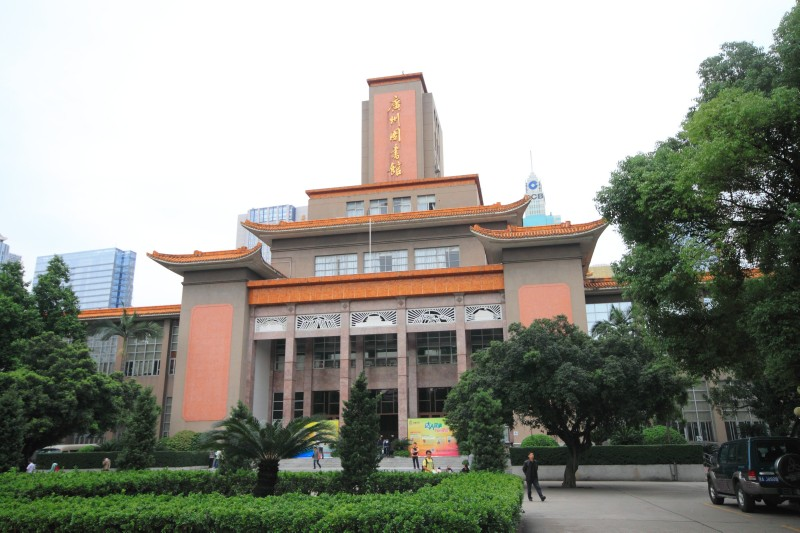

In [ ]:
basepath = "/mnt/yokoyamalab-nas/gldv2-full/"
Image.open(os.path.join(basepath, img_ids[10]["src"], f"{img_ids[10]['id']}.jpg"))

In [ ]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────────
# Dataset: /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/{train,valid,test}.csv

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Config ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path("/mnt/yokoyamalab-nas/gldv2-full/csv/v2")
OUT_DIR = Path("../outputs/eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {"train": "#4C72B0", "valid": "#DD8452", "test": "#55A868"}
SPLIT_ORDER = ["train", "valid", "test"]

plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
    }
)

# ── Load data ──────────────────────────────────────────────────────────────────
train_df = pl.read_csv(DATA_DIR / "train.csv")
valid_df = pl.read_csv(DATA_DIR / "valid.csv")
test_df = pl.read_csv(DATA_DIR / "test.csv")

# Tag each split
for df, tag in [(train_df, "train"), (valid_df, "valid"), (test_df, "test")]:
    df = df.with_columns(pl.lit(tag).alias("split"))
    if tag == "train":
        train_df = df
    elif tag == "valid":
        valid_df = df
    else:
        test_df = df

all_df = pl.concat([train_df, valid_df, test_df])
print(f"Total images: {len(all_df):,}")
all_df.head(3)


Total images: 835,161


id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption,stratify_key,split
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str,str
"""5224830a19a3f31c""",67085,34.1211,133.001,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""train""","""bridge""",0.9,"""A large suspension bridge with…","""Japan|bridge""","""train"""
"""b2d54da00a70bf24""",152227,53.006,7.192,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""train""","""bridge""",0.9,"""A red wooden bridge over a pon…","""Netherlands|bridge""","""train"""
"""843af7cc5cf86f15""",64521,48.431806,0.090278,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""arch_gate""",0.9,"""Classical French architecture …","""France|arch_gate""","""train"""


In [ ]:
# ── Table 1: Dataset split statistics ─────────────────────────────────────────
from transformers import CLIPTokenizer

clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")


def avg_token_len(df: pl.DataFrame) -> float:
    captions = df["caption"].to_list()
    tokens = clip_tokenizer(captions, padding=False, truncation=False)["input_ids"]
    return sum(len(t) for t in tokens) / len(tokens)


rows = []
for split, df in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    rows.append(
        {
            "Split": split.capitalize(),
            "#Images": len(df),
            "Avg. Text #Tokens": round(avg_token_len(df), 2),
        }
    )

stats_df = pl.DataFrame(rows)
print("Table 1 — Dataset Split Statistics")
print(stats_df)


Token indices sequence length is longer than the specified maximum sequence length for this model (109 > 77). Running this sequence through the model will result in indexing errors


Table 1 — Dataset Split Statistics
shape: (3, 3)
┌───────┬─────────┬───────────────────┐
│ Split ┆ #Images ┆ Avg. Text #Tokens │
│ ---   ┆ ---     ┆ ---               │
│ str   ┆ i64     ┆ f64               │
╞═══════╪═════════╪═══════════════════╡
│ Train ┆ 601315  ┆ 22.66             │
│ Valid ┆ 66813   ┆ 22.67             │
│ Test  ┆ 167033  ┆ 22.66             │
└───────┴─────────┴───────────────────┘


In [16]:
train_df.select("caption").to_numpy().squeeze()

array(['A large suspension bridge with tall towers, located in Japan, with vehicles on the road.',
       'A red wooden bridge over a pond in a grassy area with trees, under a partly cloudy sky in the Netherlands.',
       "Classical French architecture with ornate stone details and a balcony, featuring the name 'Opéra' above a window.",
       ...,
       'An ornate golden headpiece with intricate designs, likely part of a historical statue in Sweden.',
       'An old stone bridge with steps leading down to a canal, surrounded by greenery in the UK.',
       'White ornate door in a room, featuring intricate paneling and a classic design, located in the Netherlands.'],
      shape=(601315,), dtype=object)

In [100]:
import json
import numpy as np

with open("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/test_queries_new.json") as f:
    queries = json.load(f)["data"]

queries_df = pl.DataFrame({"caption": [q["text"] for q in queries]})
lengths = [
    len(ids)
    for ids in clip_tokenizer(
        queries_df["caption"].to_list(), padding=False, truncation=False
    )["input_ids"]
]

print(f"Queries    : {len(lengths)}")
print(f"Avg tokens : {avg_token_len(queries_df):.2f}")
print(f"Std        : {np.std(lengths):.2f}")
print(f"Min        : {min(lengths)}")
print(f"Max        : {max(lengths)}")
print(f"> 77 tokens: {sum(l > 77 for l in lengths)}")


Queries    : 450
Avg tokens : 12.66
Std        : 3.27
Min        : 6
Max        : 26
> 77 tokens: 0


In [3]:
rows

[{'Split': 'Train', '#Images': 601315, 'Avg. Text #Tokens': 22.66},
 {'Split': 'Valid', '#Images': 66813, 'Avg. Text #Tokens': 22.67},
 {'Split': 'Test', '#Images': 167033, 'Avg. Text #Tokens': 22.66}]

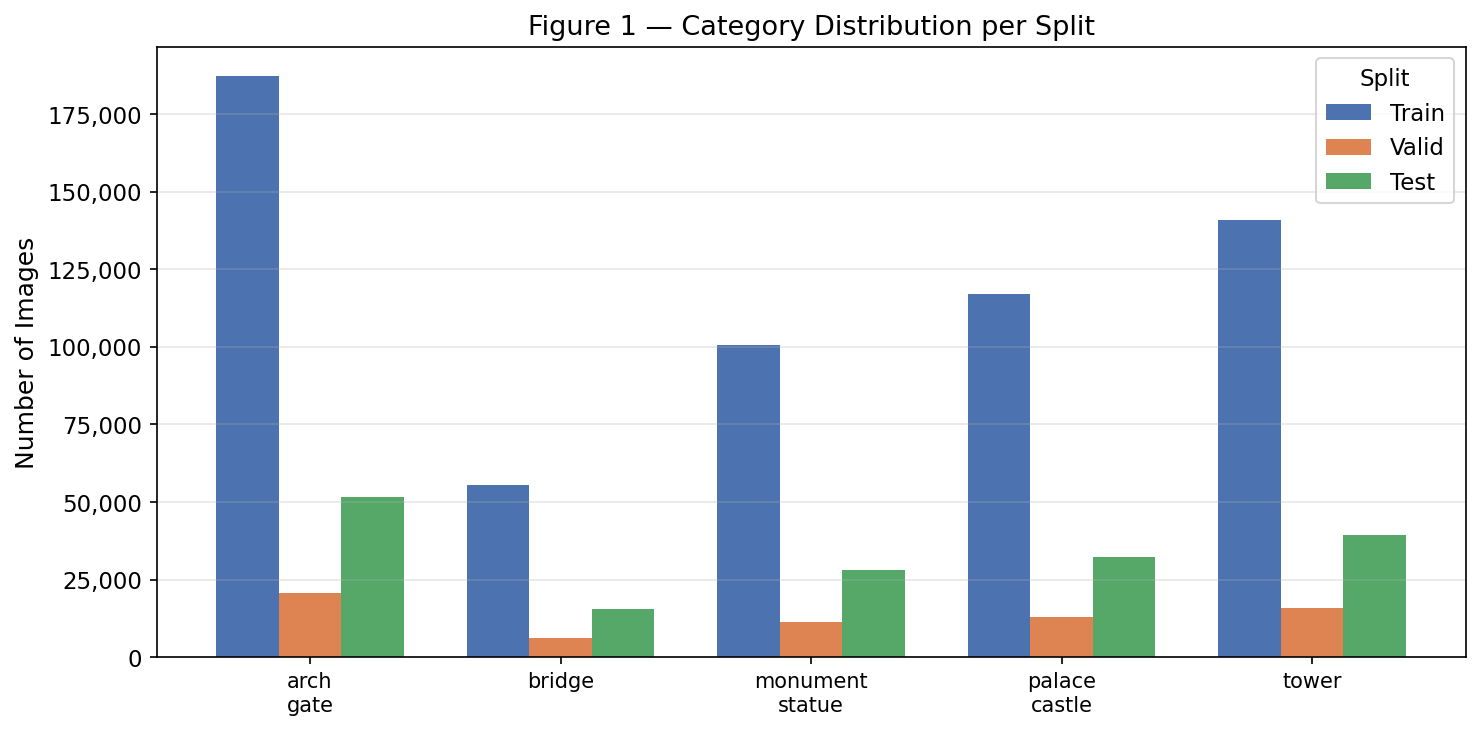

Saved → ../outputs/eda/fig1_category_distribution.png


In [ ]:
# ── Figure 1: Category distribution per split ──────────────────────────────────
# Why: reveals class imbalance and confirms stratification worked.

cat_counts = (
    all_df.group_by(["split", "pred_label"])
    .agg(pl.len().alias("count"))
    .sort(["pred_label", "split"])
    .to_pandas()
)

categories = sorted(cat_counts["pred_label"].unique())
x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, split in enumerate(SPLIT_ORDER):
    vals = [
        cat_counts.query(f"split == '{split}' and pred_label == '{c}'")["count"].values[
            0
        ]
        if len(cat_counts.query(f"split == '{split}' and pred_label == '{c}'")) > 0
        else 0
        for c in categories
    ]
    bars = ax.bar(
        x + i * width, vals, width, label=split.capitalize(), color=PALETTE[split]
    )

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace("_", "\n") for c in categories], fontsize=10)
ax.set_ylabel("Number of Images")
ax.set_title("Figure 1 — Category Distribution per Split")
ax.legend(title="Split")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig1_category_distribution.png")
plt.show()
print(f"Saved → {OUT_DIR / 'fig1_category_distribution.png'}")


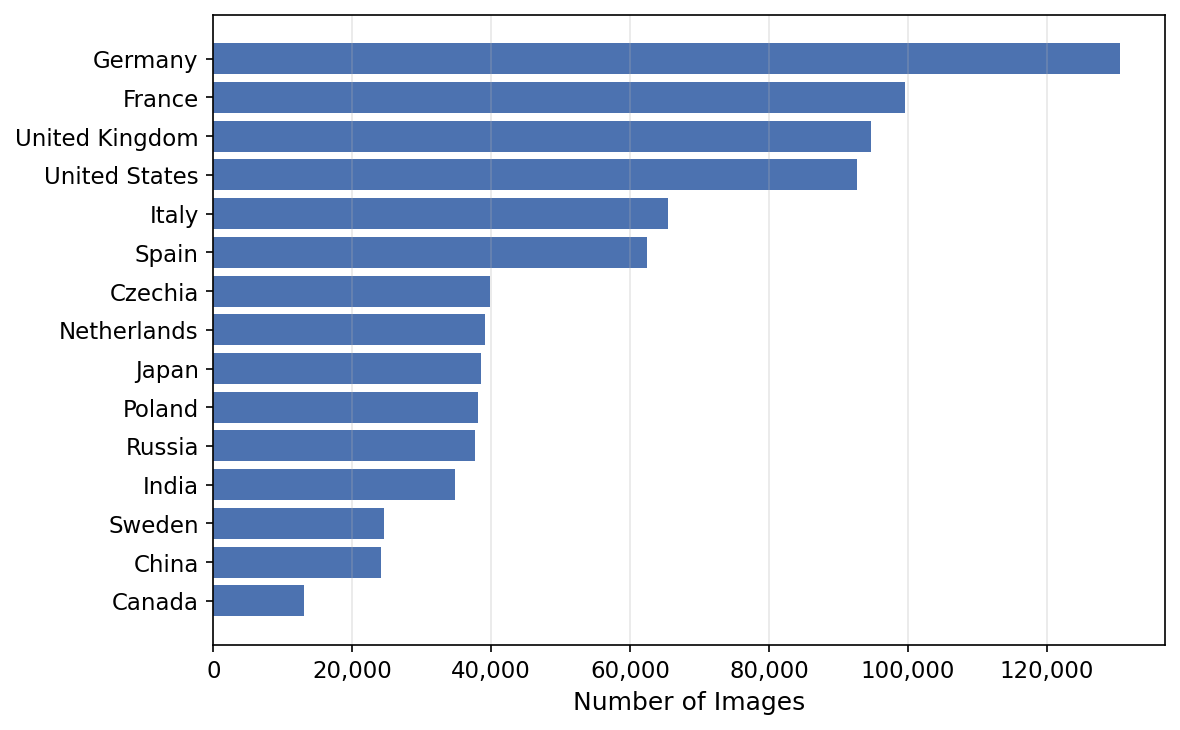

Saved → ../outputs/eda/fig2_top20_countries.png


In [ ]:
# ── Figure 2: Top-20 countries by image count (full dataset) ───────────────────
# Why: quantifies geographic bias — important for fairness discussion in the paper.

top_countries = (
    all_df.group_by("country")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(20)
    .to_pandas()
)

top_countries["country"] = top_countries["country"].str.replace(
    "Russian Federation", "Russia"
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    top_countries["country"][::-1], top_countries["count"][::-1], color="#4C72B0"
)
ax.set_xlabel("Number of Images")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "fig2_top20_countries.png")
plt.show()
print(f"Saved → {OUT_DIR / 'fig2_top20_countries.png'}")


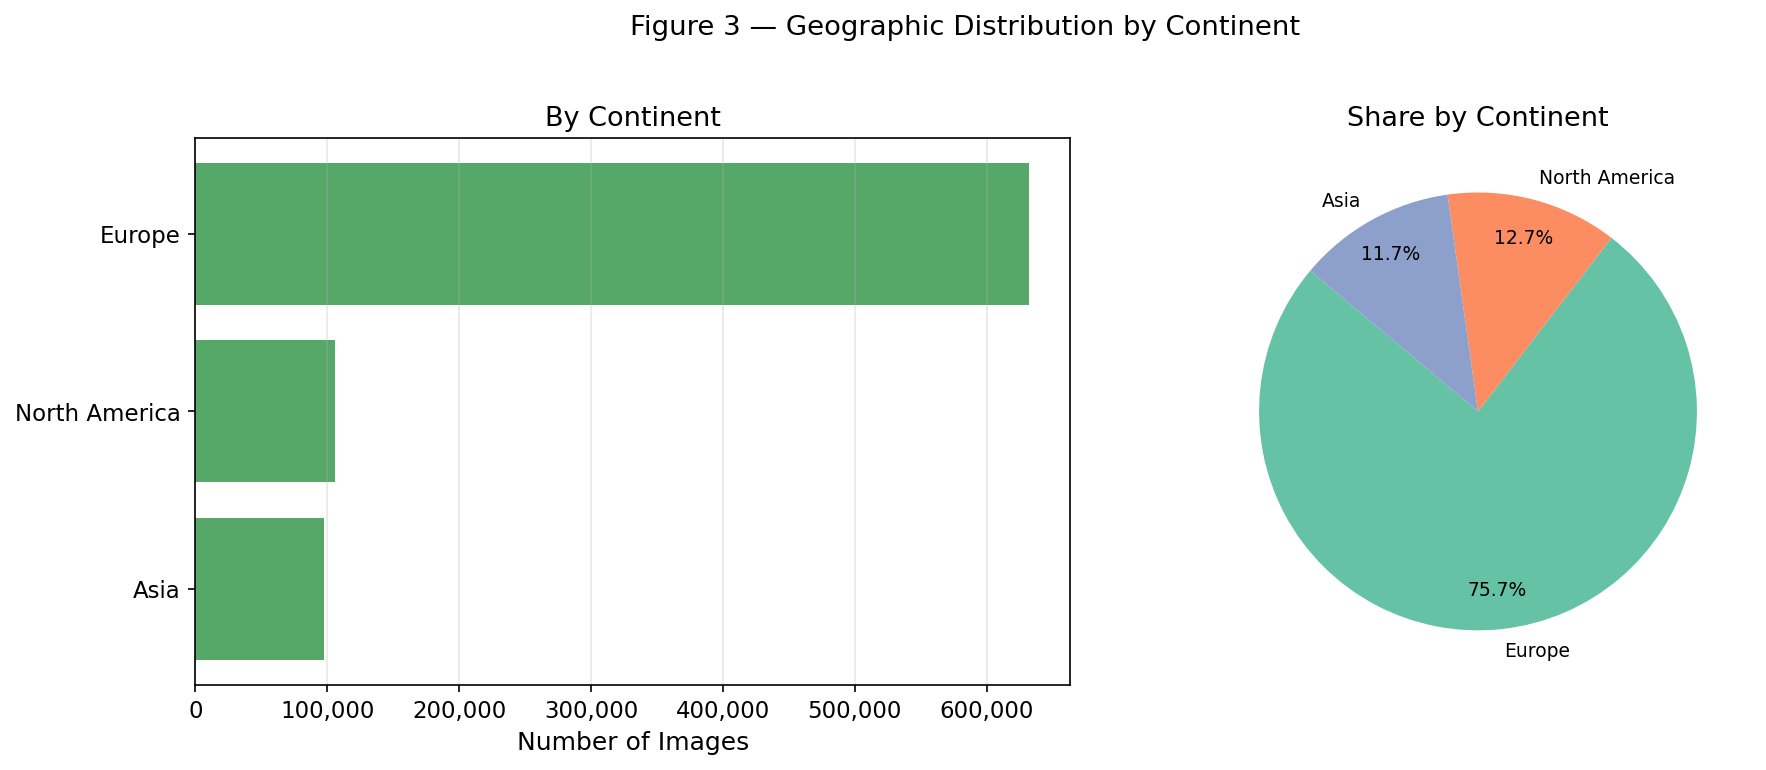

Saved → ../outputs/eda/fig3_region_distribution.png


In [ ]:
# ── Figure 3: Continental / Region distribution ────────────────────────────────
# Why: gives a coarser geographic overview that prints cleanly in a paper column.

region_counts = (
    all_df.group_by("region")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart
axes[0].barh(
    region_counts["region"][::-1], region_counts["count"][::-1], color="#55A868"
)
axes[0].set_xlabel("Number of Images")
axes[0].set_title("By Continent")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].grid(axis="x", alpha=0.3)

# Right: pie chart
wedge_colors = sns.color_palette("Set2", len(region_counts))
axes[1].pie(
    region_counts["count"],
    labels=region_counts["region"],
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.82,
    textprops={"fontsize": 9},
)
axes[1].set_title("Share by Continent")

fig.suptitle("Figure 3 — Geographic Distribution by Continent", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig3_region_distribution.png")
plt.show()
print(f"Saved → {OUT_DIR / 'fig3_region_distribution.png'}")


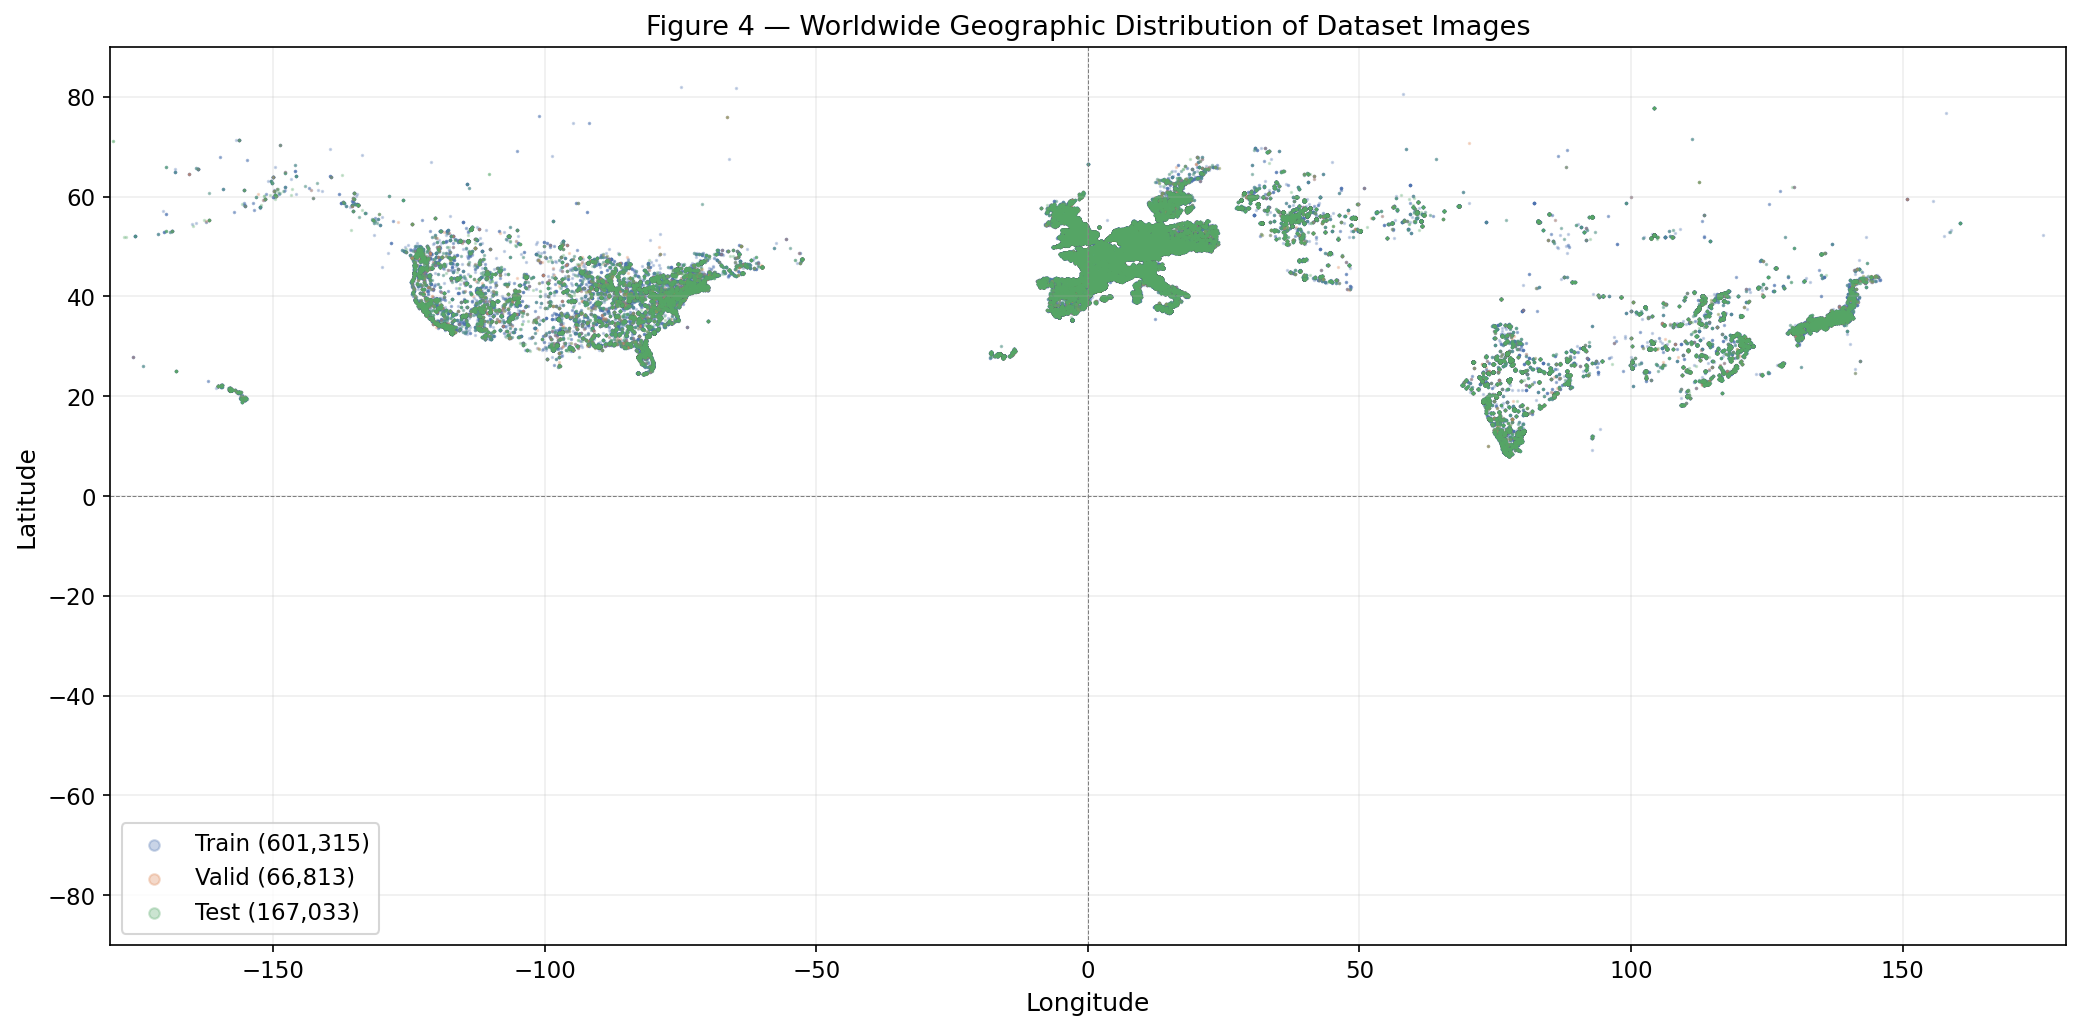

Saved → ../outputs/eda/fig4_world_map.png


In [ ]:
# ── Figure 4: World map – geographic scatter of all images ─────────────────────
# Why: the single most visually compelling figure for a geo-landmark paper.
#      Shows global reach and dense clusters simultaneously.

coords = all_df.select(["latitude", "longitude", "split"]).to_pandas()

fig, ax = plt.subplots(figsize=(14, 7))

for split in SPLIT_ORDER:
    sub = coords[coords["split"] == split]
    ax.scatter(
        sub["longitude"],
        sub["latitude"],
        s=0.4,
        alpha=0.3,
        color=PALETTE[split],
        label=f"{split.capitalize()} ({len(sub):,})",
        rasterized=True,
    )

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Figure 4 — Worldwide Geographic Distribution of Dataset Images")
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
legend = ax.legend(markerscale=8, loc="lower left", framealpha=0.8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig4_world_map.png", dpi=300)
plt.show()
print(f"Saved → {OUT_DIR / 'fig4_world_map.png'}")


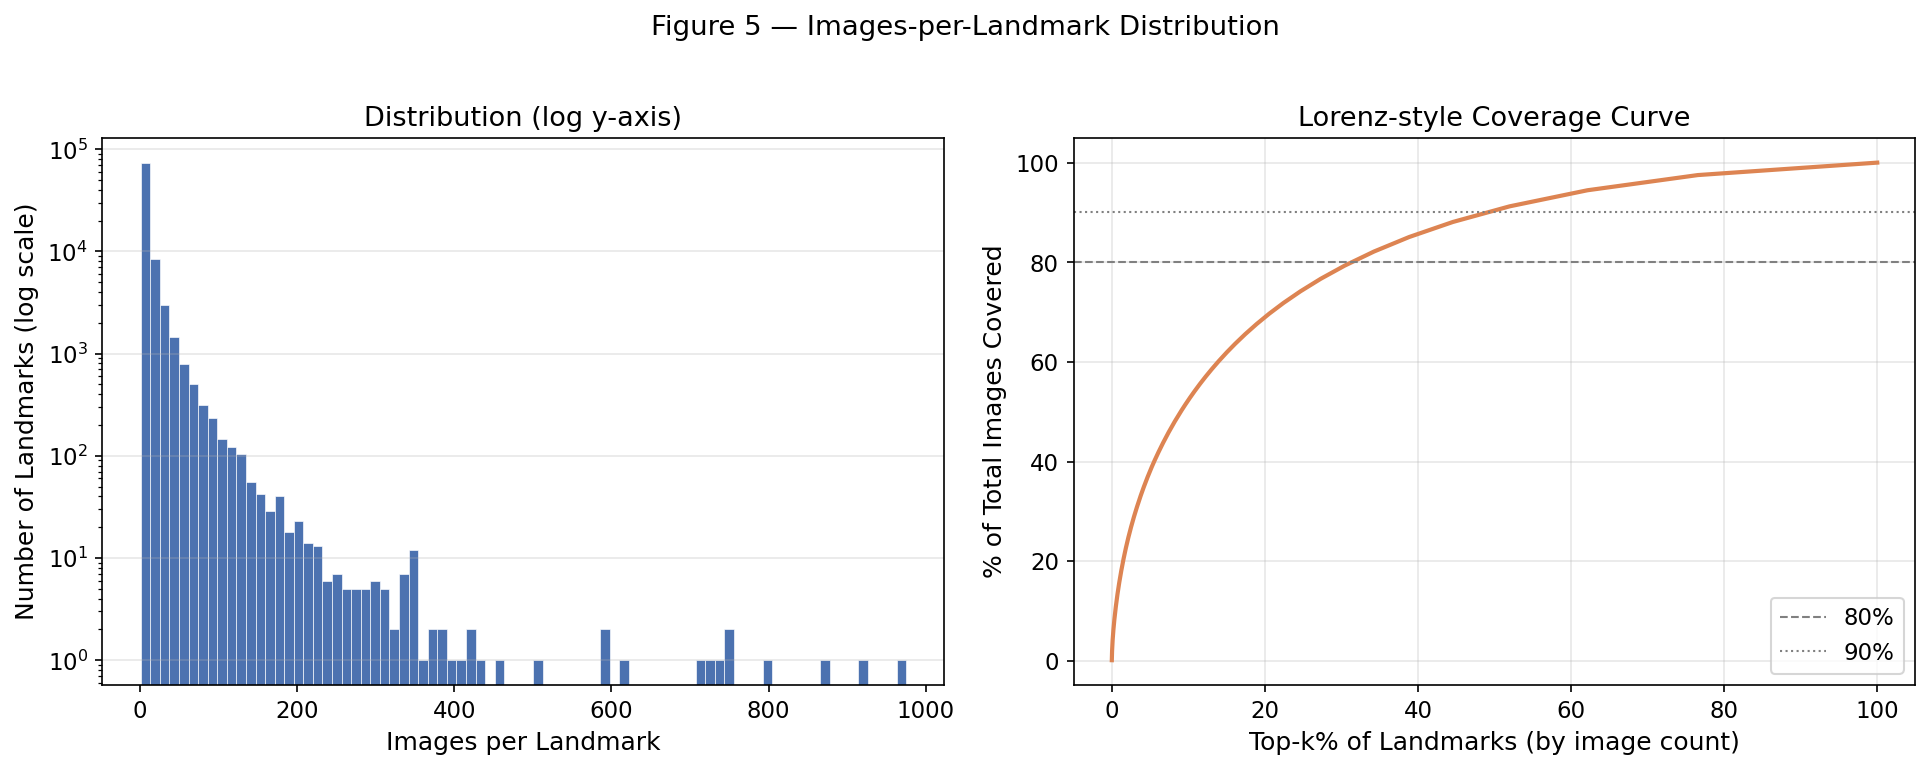

Median images/landmark: 4  |  P90: 21  |  Max: 975
Saved → ../outputs/eda/fig5_images_per_landmark.png


In [ ]:
# ── Figure 5: Images-per-landmark distribution (log scale) ─────────────────────
# Why: exposes the long-tail structure — most landmarks have few images, a few have
#      many. This directly drives retrieval difficulty and is essential context.

lm_counts = all_df.group_by("landmark_id").agg(pl.len().alias("n_images")).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: log-scale histogram
axes[0].hist(
    lm_counts["n_images"], bins=80, color="#4C72B0", edgecolor="white", linewidth=0.3
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Images per Landmark")
axes[0].set_ylabel("Number of Landmarks (log scale)")
axes[0].set_title("Distribution (log y-axis)")
axes[0].grid(axis="y", alpha=0.3)

# Right: cumulative % of data covered by top-k landmarks
lm_sorted = lm_counts.sort_values("n_images", ascending=False).reset_index(drop=True)
lm_sorted["cumsum"] = lm_sorted["n_images"].cumsum()
lm_sorted["cum_pct"] = lm_sorted["cumsum"] / lm_sorted["n_images"].sum() * 100
lm_sorted["landmark_rank_pct"] = (lm_sorted.index + 1) / len(lm_sorted) * 100

axes[1].plot(
    lm_sorted["landmark_rank_pct"], lm_sorted["cum_pct"], color="#DD8452", lw=2
)
axes[1].axhline(80, color="gray", ls="--", lw=1, label="80%")
axes[1].axhline(90, color="gray", ls=":", lw=1, label="90%")
axes[1].set_xlabel("Top-k% of Landmarks (by image count)")
axes[1].set_ylabel("% of Total Images Covered")
axes[1].set_title("Lorenz-style Coverage Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Figure 5 — Images-per-Landmark Distribution", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig5_images_per_landmark.png")
plt.show()

p50 = lm_counts["n_images"].median()
p90 = lm_counts["n_images"].quantile(0.90)
pmax = lm_counts["n_images"].max()
print(f"Median images/landmark: {p50:.0f}  |  P90: {p90:.0f}  |  Max: {pmax}")
print(f"Saved → {OUT_DIR / 'fig5_images_per_landmark.png'}")


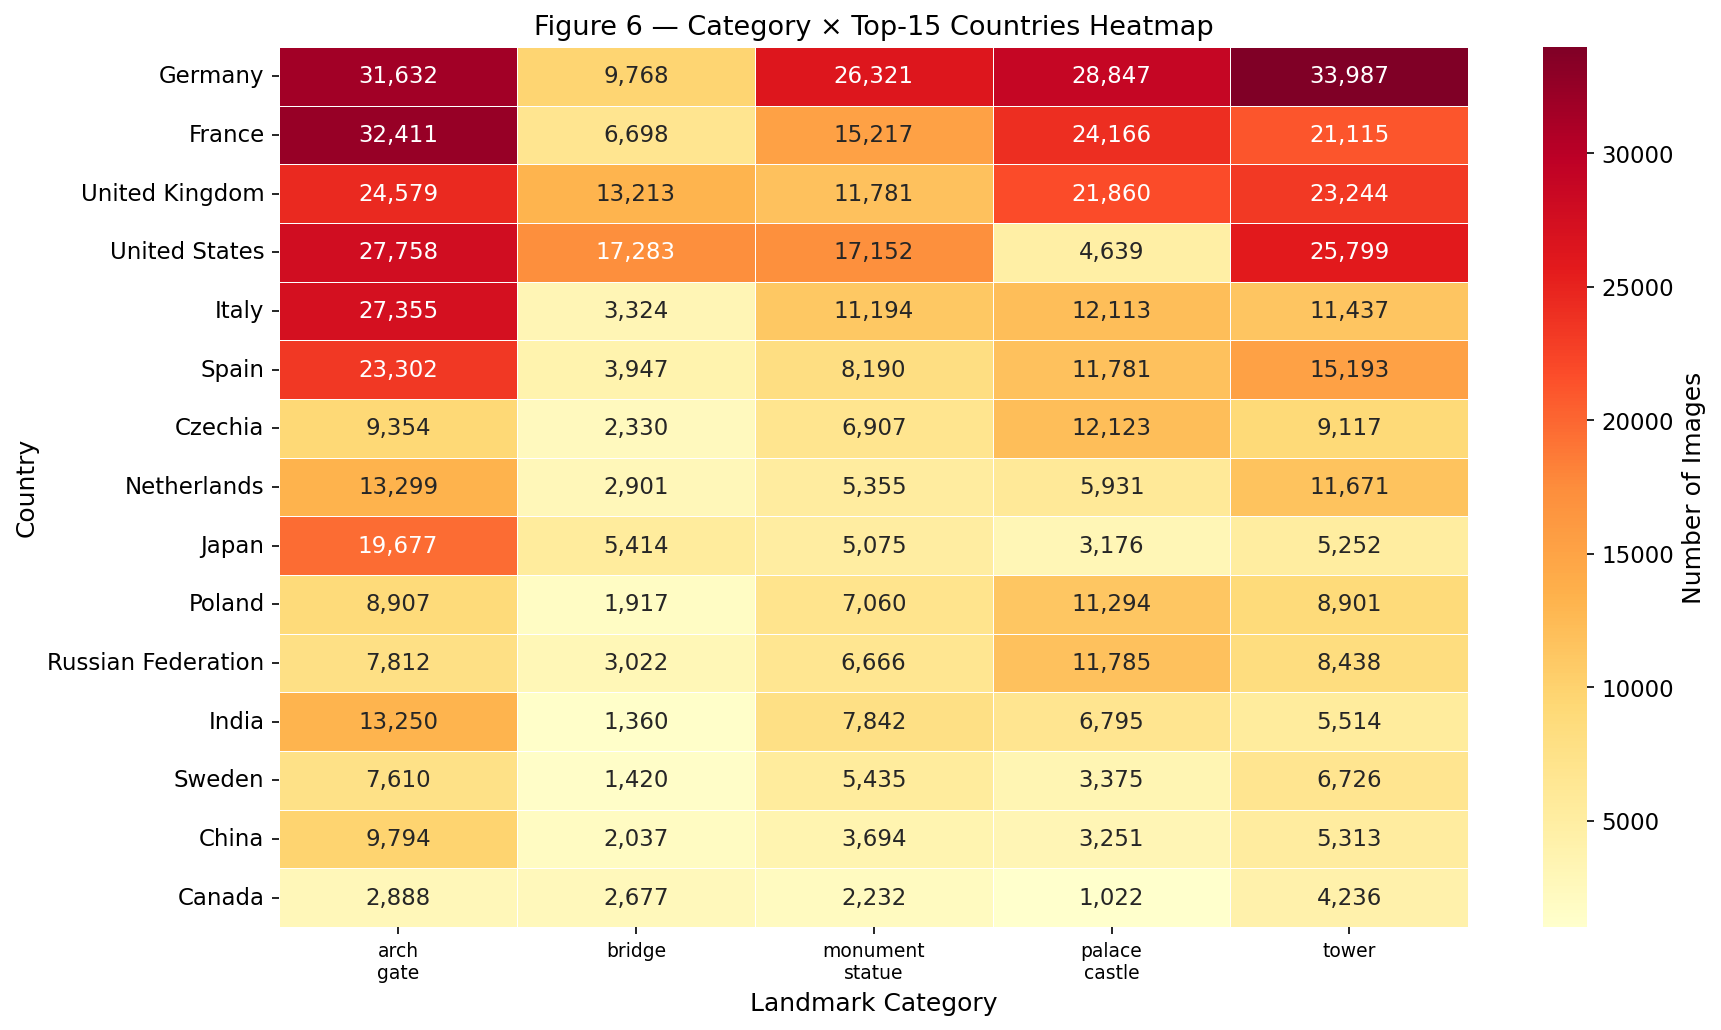

Saved → ../outputs/eda/fig6_category_country_heatmap.png


In [ ]:
# ── Figure 6: Category × Top-15 countries heatmap ─────────────────────────────
# Why: shows multivariate geo-category structure — which categories cluster in
#      which countries. Useful for understanding retrieval query composition.

TOP_N = 15
top_n_countries = (
    all_df.group_by("country")
    .agg(pl.len().alias("total"))
    .sort("total", descending=True)
    .head(TOP_N)["country"]
    .to_list()
)

heatmap_data = (
    all_df.filter(pl.col("country").is_in(top_n_countries))
    .group_by(["country", "pred_label"])
    .agg(pl.len().alias("count"))
    .to_pandas()
    .pivot(index="country", columns="pred_label", values="count")
    .fillna(0)
    .astype(int)
)
heatmap_data = heatmap_data.loc[top_n_countries]  # keep sorted order

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=",d",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Number of Images"},
)
ax.set_xlabel("Landmark Category")
ax.set_ylabel("Country")
ax.set_title(f"Figure 6 — Category × Top-{TOP_N} Countries Heatmap")
ax.set_xticklabels(
    [t.get_text().replace("_", "\n") for t in ax.get_xticklabels()], fontsize=9
)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig6_category_country_heatmap.png")
plt.show()
print(f"Saved → {OUT_DIR / 'fig6_category_country_heatmap.png'}")


In [ ]:
# ── Summary printout ───────────────────────────────────────────────────────────
print("=" * 60)
print("EDA complete. Saved figures:")
for f in sorted(OUT_DIR.glob("*.png")):
    print(f"  {f}")
print("=" * 60)
print("\nTable 1 (re-printed for convenience):")
print(stats_df)


EDA complete. Saved figures:
  ../outputs/eda/fig1_category_distribution.png
  ../outputs/eda/fig2_top20_countries.png
  ../outputs/eda/fig3_region_distribution.png
  ../outputs/eda/fig4_world_map.png
  ../outputs/eda/fig5_images_per_landmark.png
  ../outputs/eda/fig6_category_country_heatmap.png

Table 1 (re-printed for convenience):
shape: (3, 3)
┌───────┬─────────┬───────────────────┐
│ Split ┆ #Images ┆ Avg. Text #Tokens │
│ ---   ┆ ---     ┆ ---               │
│ str   ┆ i64     ┆ f64               │
╞═══════╪═════════╪═══════════════════╡
│ Train ┆ 601315  ┆ 22.66             │
│ Valid ┆ 66813   ┆ 22.67             │
│ Test  ┆ 167033  ┆ 22.66             │
└───────┴─────────┴───────────────────┘


In [22]:
from dotenv import load_dotenv
from openai import AsyncOpenAI
from PIL import Image
from pydantic import BaseModel
from tqdm.asyncio import tqdm
from typing import List

load_dotenv()

True

In [21]:
oai_cl = AsyncOpenAI()

In [23]:
class AugmentCaption(BaseModel):
    augmented_captions: List[str]

In [94]:
prompt = """You are generating search queries for evaluating a geographic landmark image retrieval system.
You will be given various of captions containing country and landmark label attributes.
Your task is to generate {N} variations of the given captions.
You may combine some of them and formulate new and distinct queries.
The only thing you need to remember is to keep the generated queries generic.
Do not mention too specific features depicted from the caption.

Captions:
{query}
"""

In [95]:
N = 10
tasks = []

In [96]:
# async def call_oai(row_idx: int, caption: str):
async def call_oai(item: dict):
    output = await oai_cl.responses.parse(
        model="gpt-5-mini",
        text_format=AugmentCaption,
        input=[
            {
                "role": "system",
                "content": prompt.format(
                    **{
                        "query": item["caption"],
                        "N": N,
                    }
                ),
            },
        ],
    )
    return {
        "stratify_key": item["stratify_key"],
        "augmented_captions": output.output[1].content[0].parsed.augmented_captions,
    }


In [97]:
test_captions = test_df.group_by("stratify_key").agg("caption").to_dicts()

In [98]:
for tc in test_captions:
    tc["caption"] = "\n".join(tc["caption"])

In [99]:
tasks = [call_oai(qc) for qc in test_captions]
results = await tqdm.gather(*tasks, desc="augmenting captions")

augmenting captions:   0%|          | 0/75 [00:04<?, ?it/s]


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-5-mini in organization org-zb0SnYcA64ieYyLcUgX6011g on tokens per min (TPM): Limit 2000000, Used 2000000, Requested 51371. Please try again in 1.541s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [ ]:
import sys

sys.path.append("..")
from src.data.query_builder import build_queries

queries = build_queries(
    test_df.rename({"pred_label": "category"}).with_row_index("row_idx")
)

In [ ]:
query_df =  pl.DataFrame(queries).with_columns(pl.concat_str(["country", "category"], separator="|").alias("stratify_key"))

In [ ]:
generated_df = pl.DataFrame(results).explode("augmented_captions")

In [77]:
query_df.join(generated_df, on="stratify_key")

text,category,country,relevant_indices,stratify_key,augmented_captions
str,str,str,list[i64],str,str
"""A bridge landmark located in U…","""bridge""","""United Kingdom""","[84, 90, … 166994]","""United Kingdom|bridge""","""historic stone bridge with arc…"
"""A bridge landmark located in U…","""bridge""","""United Kingdom""","[84, 90, … 166994]","""United Kingdom|bridge""","""long seaside pier extending in…"
"""A bridge landmark located in U…","""bridge""","""United Kingdom""","[84, 90, … 166994]","""United Kingdom|bridge""","""large suspension bridge spanni…"
"""A bridge landmark located in U…","""bridge""","""United Kingdom""","[84, 90, … 166994]","""United Kingdom|bridge""","""modern pedestrian or cable-sta…"
"""A bridge landmark located in U…","""bridge""","""United Kingdom""","[84, 90, … 166994]","""United Kingdom|bridge""","""harbour or port scene with lar…"
…,…,…,…,…,…
"""A monument_statue landmark loc…","""monument_statue""","""Poland""","[163, 283, … 166961]","""Poland|monument_statue""","""Historic monument or statue in…"
"""A monument_statue landmark loc…","""monument_statue""","""Poland""","[163, 283, … 166961]","""Poland|monument_statue""","""Stone cross or cemetery memori…"
"""A monument_statue landmark loc…","""monument_statue""","""Poland""","[163, 283, … 166961]","""Poland|monument_statue""","""Bronze sculpture or equestrian…"


In [84]:
# uk_queries = [
#     q for q in queries if q["category"] == "bridge" and q["country"] == "United Kingdom"
# ]
# sample = uk_queries[0]

# print(len(uk_queries))
new_queries = []
for res in results:
    country, category = res["stratify_key"].split("|")
    sample = list(filter(lambda x: (x["category"] == category) and (x["country"] == country), queries))[0]
    new_queries.append(sample)
    for r in res["augmented_captions"]:
        item = sample.copy()
        item["text"] = r
        new_queries.append(item)

# print(len(uk_queries))
len(new_queries)

450

In [88]:
import json

with open("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/test_queries_new.json", "w") as f:
    f.write(json.dumps({"data": new_queries}))

In [103]:
for q in new_queries[:7]:
    print(q["text"])

A bridge landmark located in United Kingdom
historic stone bridge with arches in the United Kingdom
long seaside pier extending into the water in the United Kingdom
large suspension bridge spanning a body of water in the United Kingdom
modern pedestrian or cable-stayed bridge in an urban UK setting
harbour or port scene with large ships and cranes in the United Kingdom
A palace_castle landmark located in France
